In [3]:
# Purpose of batch norm = more robust gain of linear layers and whether we need to apply fan_in (play with lr if needed)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
# build the vocabulary of characters and mappings
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the data set
block_size = 3 # context length: how many chars are considered when predicting the next char

def build_dataset(words):
    X, Y = [],[]

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context) # stores the context for each char
            Y.append(ix) # stores the char
            context = context[1:] + [ix] # crop and append the new char to context

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # Training set (80%)
Xdev, Ydev = build_dataset(words[n1:n2]) # Dev set (10%)
Xte, Yte = build_dataset(words[n2:]) # Test set (10%)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
# Training a deeper network

class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5 # initiate with random nums drawn from a gaussian with Kaiming Normal
        self.bias = torch.zeros(fan_out) if bias else None # initiate bias to 0

    def __call__(self, x): # Wx + b
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True # may want to set to false for evaluation mode
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim) # used to scale
        self.beta = torch.zeros(dim) # used to shift
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training: # during training we use batch statistics
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else: # during inference (evaluation) we use the running statistics
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # .out attribute created for modeling, but not typical in pytorch
        # update the buffers
        if self.training:
            with torch.no_grad(): # exponential moving average
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_embd = 10 # dimensionality of character embedding vector
n_hidden = 100 # num neurons in hidden layer of MLP
g = torch.Generator().manual_seed(2147483647) # reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size), 
]

'''
NOTE: if we had all linear layers:
- forward pass "collapses" into one large linear layer (just a simple linear transformation)
- backward pass -> can still be useful because of different training dynamics for each linear layer
'''

with torch.no_grad():
    # last layer: make less confident
    # layers[-1].weight *= 0.1 # linear (no batch norm) last layer
    layers[-1].gamma *= 0.1 # batch norm last layer
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # boost linear layers by gain -> stabilizes layers to have a stdev around 0.65
                                # without this, stdev goes to 0 = layer shrinks to tanh = 0 (activations = 0) for all/most neurons
                                # too large gain = layer becomes saturated (all/most neurons activated near the extremes of tanh)
                                # graidients: want all layers to have roughly same gradient
                                # too small gain = gradients expanding out
                                # too high gain = asymmetry in gradients
                                # without bn = need to carefully set gain

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

47551


In [39]:
# Optimization

max_steps = 200000
batch_size = 32
lossi = []
ud = [] # update to data ratio

for i in range(max_steps):

    # mini batch construct
    # activations will differ (jitter) between batches because they depend on what other examples are in the batch (which is random)
    # works as a regularizer -> harder to overfit the network
    ix = torch.randint(0, Xtr.shape[0], (batch_size,),generator = g) # randomly selects a mini batch size
    Xb, Yb = Xtr[ix], Ytr[ix] # mini batch

    # forward pass
    emb = C[Xb] # embed the chars into vectors
    x = emb.view(emb.shape[0], -1) # concatenates the vectors for multiplication
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # retain gradients of outputs AFTER_DEBUG: would take out retain_graph <- his annotation
    for p in parameters:
        p.grad = None # set gradients of parameters to 0
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad # update = learning rate * gradient

    # track stats
    if i % 10000 == 0: # print every 10,000 iterations
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters]) # log(stdev of update/stdev of data)

    if i > 1000:
        break

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.97%
layer 5 (      Tanh): mean +0.01, std 0.64, saturated: 2.41%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.44%
layer 11 (      Tanh): mean +0.00, std 0.64, saturated: 2.22%
layer 14 (      Tanh): mean -0.00, std 0.64, saturated: 2.25%


Text(0.5, 1.0, 'activation distribution')

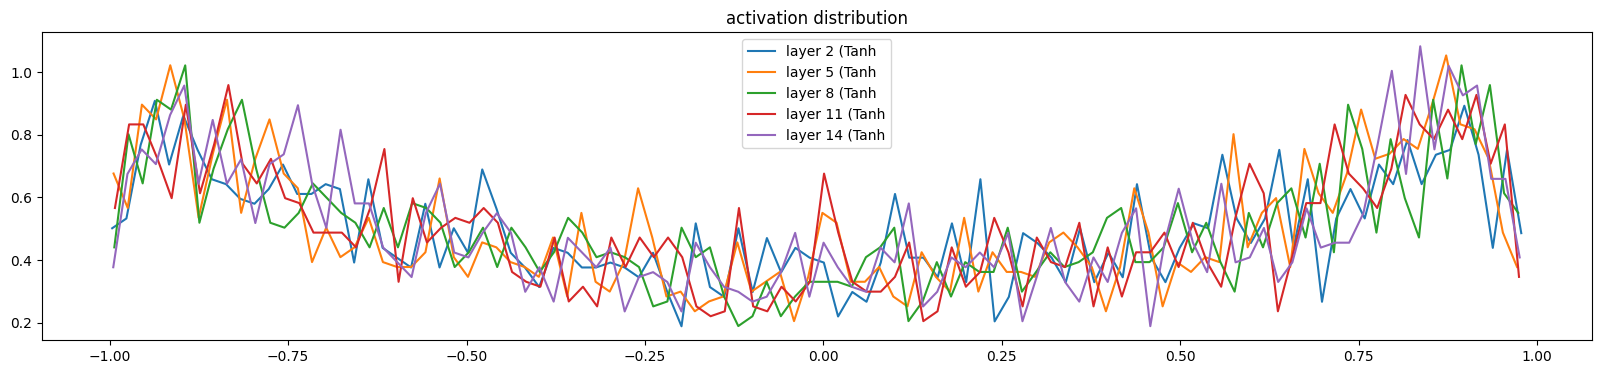

In [40]:
# visualize histograms -> activations

# boost linear layers by gain -> stabilizes layers to have a stdev around 0.65
# without this, stdev goes to 0 = layer shrinks to tanh = 0 (activations = 0) for all/most neurons
# too large gain = layer becomes saturated (all/most neurons activated near the extremes of tanh)

plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 3.561966e-03
layer 5 (      Tanh): mean +0.000000, std 3.119518e-03
layer 8 (      Tanh): mean -0.000000, std 2.904400e-03
layer 11 (      Tanh): mean +0.000000, std 2.580220e-03
layer 14 (      Tanh): mean -0.000000, std 2.440870e-03


Text(0.5, 1.0, 'gradient distribution')

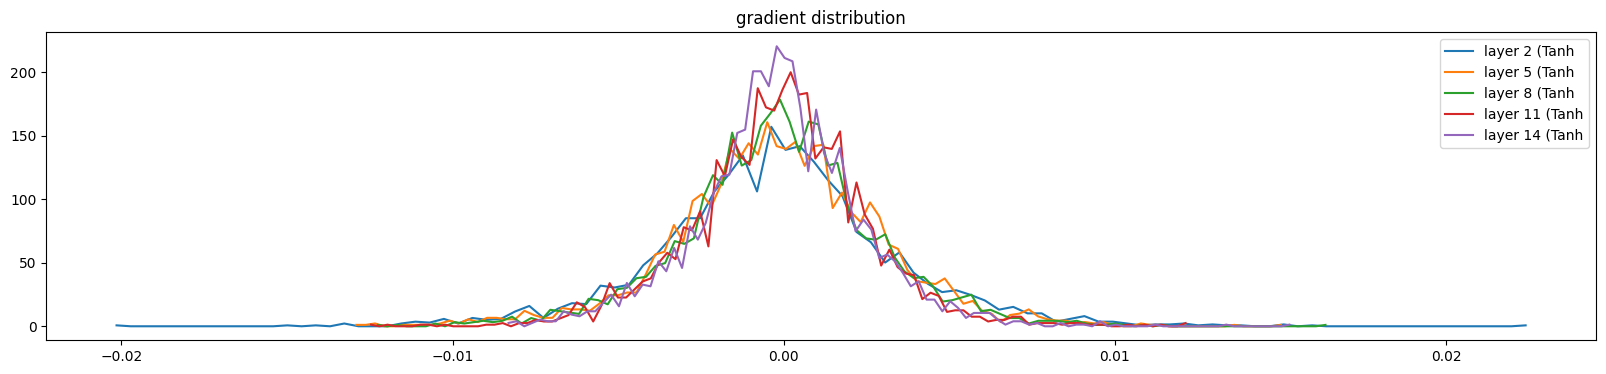

In [42]:
# visualize histograms -> gradients

# graidients: want all layers to have roughly same gradient
# too small gain = gradients expanding out
# too high gain = asymmetry in gradients
# without bn = need to carefully set gain

plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 8.198623e-03 | grad:data ratio 8.190264e-03
weight  (30, 100) | mean -0.000195 | std 7.650370e-03 | grad:data ratio 2.447689e-02
weight (100, 100) | mean -0.000097 | std 6.207552e-03 | grad:data ratio 3.712864e-02
weight (100, 100) | mean +0.000015 | std 5.561911e-03 | grad:data ratio 3.297624e-02
weight (100, 100) | mean +0.000008 | std 5.220591e-03 | grad:data ratio 3.110145e-02
weight (100, 100) | mean +0.000029 | std 4.829151e-03 | grad:data ratio 2.876363e-02
weight  (100, 27) | mean -0.000014 | std 9.281198e-03 | grad:data ratio 5.568808e-02


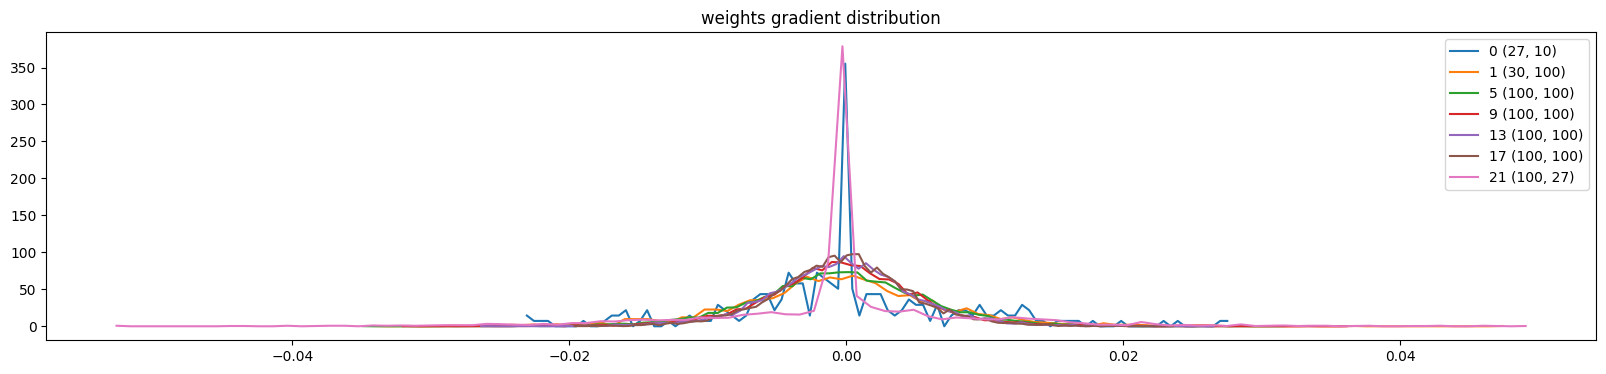

In [43]:
# visualize histograms -> gradient to data ratio

# higher ratio for last layer means we are training it ~10x faster than other layers -> fixes through iterations

plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2: # 2D parameters = weights, skipping biases, gamma, and beta
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

'\n- last layer has high ratio because of we lowered its softmax/confidence\n- too small learning rate = ratios will be way too low (barely changing parameters)\n'

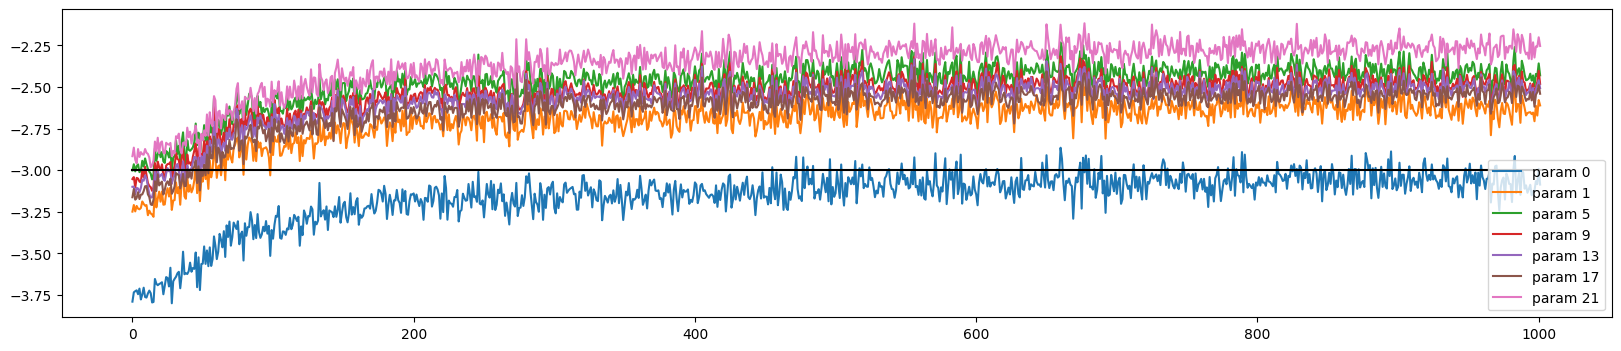

In [44]:
# update to data ratio

plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2: # constrain to weights
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot (higher values = updating faster)
plt.legend(legends);

'''
- last layer has high ratio because of we lowered its softmax/confidence
- too small learning rate = ratios will be way too low (barely changing parameters)
- for batch norm, this is affected by changing the gain
- will need to change learning rate if you change scale of activations coming into the batch norm
'''

In [ ]:
'''
SUMMARY:
- Batch Normalization -> one of the first techniques used to stabilize deep neural networks
--- Performance is no longer bottle necked by optimization
--- Now bottle necked by context length
--- Need to use more complex models

- This is essentially identical to the api that pytorch uses to initiate Linear and BatchNorm1d layers
- Could change this to have nn.Linear and nn.BatchNorm1d and would work
- Use histograms for diagnostics to assess model
- Track the histograms over time to assess model

- Look into why we need to change learning rate if gain is too high/too low -> part of backward pass, which we didn't cover here
'''